In [1]:
import importlib
import sys
import numpy as np
from collections import Counter
import pandas as pd

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')

In [2]:
import event_log_loader.new_event_log_loader_v2
importlib.reload(event_log_loader.new_event_log_loader_v2)
from event_log_loader.new_event_log_loader_v2 import PrefixesDataFrameLoader, EventLogLoader

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(17)

event_log_location = '../../../../../../data/data/BPI Challenge 2017.csv'

result_name = 'bpic17_all'

# dynamic categorical attributes
cat_dynamic = ['concept:name',
               # 'EventOrigin'
               'lifecycle:transition',
               'org:resource'
              ]

# static categorical attributes
cat_static = ['case:LoanGoal',
              'case:ApplicationType',
              'Accepted',
              'Selected'
             ]

# dynamic numerical attributes
num_dynamic = ['case_elapsed_time',
               'event_elapsed_time',
               'day_in_week',
               'seconds_in_day',
               ]

# dynamic log-normal encoded numerical attributes 
num_dyn_log = []

# static numeric attributes
num_static = ['case:RequestedAmount',
              'FirstWithdrawalAmount',
              'NumberOfTerms',
              'MonthlyCost',
              'CreditScore'
              ]

min_suffix_size = 5

event_log_properties = {# case id
                        'case_name' : 'case:concept:name',
                        # activity
                        'concept_name' : 'concept:name',
                        # time values and computaitons
                        'timestamp_name' : 'time:timestamp',
                        'time_since_case_start_column' : 'case_elapsed_time',
                        'time_since_last_event_column' : 'event_elapsed_time',
                        'day_in_week_column' : 'day_in_week',
                        'seconds_in_day_column' : 'seconds_in_day',
                        # min suffix size for eos padding right
                        'min_suffix_size' : min_suffix_size,
                        # trian and test split
                        'train_validation_size' : 0.15,
                        'test_validation_size' : 0.2,
                        # window size for padding
                        'window_size' : 'auto',
                        # dynamic and static values
                        'categorical_columns' : cat_dynamic,
                        'static_categorical_columns' : cat_static,
                        'continuous_columns' : num_dynamic,
                        'continuous_positive_columns' : num_dyn_log,
                        'static_continuous_columns' : num_static}


## Create dataframes of prefixes

In [3]:
# object to create datframe of prefixes for petri-net repaly marking computation
pref_adopt_dataframe = PrefixesDataFrameLoader(event_log_location=event_log_location, event_log_properties=event_log_properties)

In [4]:
# output if necessary the raw dataframe: dynamic are lists, static values
raw_data = pref_adopt_dataframe.get_raw_dataframe()
raw_data

unique_vals = (
    pd.Series(raw_data["concept:name"])
      .explode()
      .dropna()
      .unique()
      .tolist()
)

print(unique_vals)


['A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Complete application', 'A_Concept', 'A_Accepted', 'O_Create Offer', 'O_Created', 'O_Sent (mail and online)', 'W_Call after offers', 'A_Complete', 'A_Cancelled', 'O_Cancelled', 'W_Validate application', 'A_Validating', 'O_Returned', 'O_Accepted', 'A_Pending', 'W_Call incomplete files', 'A_Incomplete', 'A_Denied', 'O_Refused', 'O_Sent (online only)', 'W_Assess potential fraud', 'W_Shortened completion ', 'W_Personal Loan collection']


In [5]:
# outputs for perturbations:
# train_df, val_df, test_df = pref_adopt_dataframe.get_all_datasets()
# categories = pref_adopt_dataframe.extract_feature_info()

In [6]:
# prefix dataset for potential marking computation
train_pref_df = pref_adopt_dataframe.get_dataset('train')
train_pref_df

,case:concept:name,prefix_length,concept:name,lifecycle:transition,org:resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:LoanGoal,case:ApplicationType,Accepted,Selected,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,MonthlyCost,CreditScore
0,Application_1000311556,1,[A_Create Application],[complete],[User_71],[0.0],[nan],[0.0],[57397.0],Car,New credit,True,False,45000.0,0.0,111.0,500.0,0.0
1,Application_1000311556,2,"[A_Create Application, W_Complete application]","[complete, schedule]","[User_71, User_71]","[0.0, 0.013000000268220901]","[nan, 0.013000000268220901]","[0.0, 0.0]","[57397.0, 57397.0]",Car,New credit,True,False,45000.0,0.0,111.0,500.0,0.0
2,Application_1000311556,3,"[A_Create Application, W_Complete application,...","[complete, schedule, start]","[User_71, User_71, User_71]","[0.0, 0.013000000268220901, 0.017999999225139618]","[nan, 0.013000000268220901, 0.004999999888241291]","[0.0, 0.0, 0.0]","[57397.0, 57397.0, 57397.0]",Car,New credit,True,False,45000.0,0.0,111.0,500.0,0.0
3,Application_1000311556,4,"[A_Create Application, W_Complete application,...","[complete, schedule, start, complete]","[User_71, User_71, User_71, User_71]","[0.0, 0.013000000268220901, 0.0179999992251396...","[nan, 0.013000000268220901, 0.0049999998882412...","[0.0, 0.0, 0.0, 0.0]","[57397.0, 57397.0, 57397.0, 57397.0]",Car,New credit,True,False,45000.0,0.0,111.0,500.0,0.0
4,Application_1000311556,5,"[A_Create Application, W_Complete application,...","[complete, schedule, start, complete, complete]","[User_71, User_71, User_71, User_71, User_71]","[0.0, 0.013000000268220901, 0.0179999992251396...","[nan, 0.013000000268220901, 0.0049999998882412...","[0.0, 0.0, 0.0, 0.0, 0.0]","[57397.0, 57397.0, 57397.0, 57397.0, 57989.0]",Car,New credit,True,False,45000.0,0.0,111.0,500.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
779855,Application_999993467,33,"[A_Create Application, A_Concept, W_Complete a...","[complete, complete, schedule, start, suspend,...","[User_23, User_23, User_23, User_23, User_23, ...","[0.0, 0.003000000026077032, 0.0140000004321336...","[nan, 0.003000000026077032, 0.0109999999403953...","[1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0, ...","[58862.0, 58862.0, 58862.0, 58862.0, 58877.0, ...",Home improvement,Limit raise,False,False,10000.0,0.0,134.0,100.0,0.0
779856,Application_999993467,34,"[A_Create Application, A_Concept, W_Complete a...","[complete, complete, schedule, start, suspend,...","[User_23, User_23, User_23, User_23, User_23, ...","[0.0, 0.003000000026077032, 0.0140000004321336...","[nan, 0.003000000026077032, 0.0109999999403953...","[1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0, ...","[58862.0, 58862.0, 58862.0, 58862.0, 58877.0, ...",Home improvement,Limit raise,False,False,10000.0,0.0,134.0,100.0,0.0
779857,Application_999993467,35,"[A_Create Application, A_Concept, W_Complete a...","[complete, complete, schedule, start, suspend,...","[User_23, User_23, User_23, User_23, User_23, ...","[0.0, 0.003000000026077032, 0.0140000004321336...","[nan, 0.003000000026077032, 0.0109999999403953...","[1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0, ...","[58862.0, 58862.0, 58862.0, 58862.0, 58877.0, ...",Home improvement,Limit raise,False,False,10000.0,0.0,134.0,100.0,0.0
779858,Application_999993467,36,"[A_Create Application, A_Concept, W_Complete a...","[complete, complete, schedule, start, suspend,...","[User_23, User_23, User_23, User_23, User_23, ...","[0.0, 0.003000000026077032, 0.0140000004321336...","[nan, 0.003000000026077032, 0.0109999999403953...","[1.0, 1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0, ...","[58862.0, 58862.0, 58862.0, 58862.0, 58877.0, ...",Home improvement,Limit raise,False,False,10000.0,0.0,134.0,100.0,0.0


In [7]:
train_pref_df.to_csv('../../../../encoded_data_v2/BPIC17/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_train.csv', index=False)

In [8]:
# prefix dataset for potential marking computation
val_pref_df = pref_adopt_dataframe.get_dataset('val')
val_pref_df

,case:concept:name,prefix_length,concept:name,lifecycle:transition,org:resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:LoanGoal,case:ApplicationType,Accepted,Selected,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,MonthlyCost,CreditScore
0,Application_1000158214,1,[A_Create Application],[complete],[User_1],[0.0],[nan],[3.0],[36866.0],Home improvement,New credit,True,True,12500.0,0.0,57.0,250.00,929.0
1,Application_1000158214,2,"[A_Create Application, A_Submitted]","[complete, complete]","[User_1, User_1]","[0.0, 0.04100000113248825]","[nan, 0.04100000113248825]","[3.0, 3.0]","[36866.0, 36866.0]",Home improvement,New credit,True,True,12500.0,0.0,57.0,250.00,929.0
2,Application_1000158214,3,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule]","[User_1, User_1, User_1]","[0.0, 0.04100000113248825, 0.382999986410141]","[nan, 0.04100000113248825, 0.34200000762939453]","[3.0, 3.0, 3.0]","[36866.0, 36866.0, 36867.0]",Home improvement,New credit,True,True,12500.0,0.0,57.0,250.00,929.0
3,Application_1000158214,4,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule, withdraw]","[User_1, User_1, User_1, User_1]","[0.0, 0.04100000113248825, 0.382999986410141, ...","[nan, 0.04100000113248825, 0.34200000762939453...","[3.0, 3.0, 3.0, 3.0]","[36866.0, 36866.0, 36867.0, 36936.0]",Home improvement,New credit,True,True,12500.0,0.0,57.0,250.00,929.0
4,Application_1000158214,5,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule, withdraw, sched...","[User_1, User_1, User_1, User_1, User_1]","[0.0, 0.04100000113248825, 0.382999986410141, ...","[nan, 0.04100000113248825, 0.34200000762939453...","[3.0, 3.0, 3.0, 3.0, 3.0]","[36866.0, 36866.0, 36867.0, 36936.0, 36936.0]",Home improvement,New credit,True,True,12500.0,0.0,57.0,250.00,929.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181808,Application_999993812,31,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule, withdraw, sched...","[User_1, User_1, User_1, User_1, User_1, User_...","[0.0, 0.7480000257492065, 0.9670000076293945, ...","[nan, 0.7480000257492065, 0.21899999678134918,...","[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 4.0, 4.0, 0.0, ...","[50224.0, 50224.0, 50225.0, 50302.0, 50302.0, ...",Caravan / Camper,New credit,True,True,30000.0,30000.0,102.0,349.13,877.0
181809,Application_999993812,32,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule, withdraw, sched...","[User_1, User_1, User_1, User_1, User_1, User_...","[0.0, 0.7480000257492065, 0.9670000076293945, ...","[nan, 0.7480000257492065, 0.21899999678134918,...","[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 4.0, 4.0, 0.0, ...","[50224.0, 50224.0, 50225.0, 50302.0, 50302.0, ...",Caravan / Camper,New credit,True,True,30000.0,30000.0,102.0,349.13,877.0
181810,Application_999993812,33,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule, withdraw, sched...","[User_1, User_1, User_1, User_1, User_1, User_...","[0.0, 0.7480000257492065, 0.9670000076293945, ...","[nan, 0.7480000257492065, 0.21899999678134918,...","[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 4.0, 4.0, 0.0, ...","[50224.0, 50224.0, 50225.0, 50302.0, 50302.0, ...",Caravan / Camper,New credit,True,True,30000.0,30000.0,102.0,349.13,877.0
181811,Application_999993812,34,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule, withdraw, sched...","[User_1, User_1, User_1, User_1, User_1, User_...","[0.0, 0.7480000257492065, 0.9670000076293945, ...","[nan, 0.7480000257492065, 0.21899999678134918,...","[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 4.0, 4.0, 0.0, ...","[50224.0, 50224.0, 50225.0, 50302.0, 50302.0, ...",Caravan / Camper,New credit,True,True,30000.0,30000.0,102.0,349.13,877.0


In [9]:
val_pref_df.to_csv('../../../../encoded_data_v2/BPIC17/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_val.csv', index=False)

In [10]:
# prefix dataset for potential marking computation
test_pref_df = pref_adopt_dataframe.get_dataset('test')
test_pref_df

,case:concept:name,prefix_length,concept:name,lifecycle:transition,org:resource,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day,case:LoanGoal,case:ApplicationType,Accepted,Selected,case:RequestedAmount,FirstWithdrawalAmount,NumberOfTerms,MonthlyCost,CreditScore
0,Application_1000086665,1,[A_Create Application],[complete],[User_1],[0.0],[nan],[2.0],[57441.0],"Other, see explanation",New credit,True,False,5000.0,5000.0,22.0,241.28,0.0
1,Application_1000086665,2,"[A_Create Application, A_Submitted]","[complete, complete]","[User_1, User_1]","[0.0, 0.061000000685453415]","[nan, 0.061000000685453415]","[2.0, 2.0]","[57441.0, 57441.0]","Other, see explanation",New credit,True,False,5000.0,5000.0,22.0,241.28,0.0
2,Application_1000086665,3,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule]","[User_1, User_1, User_1]","[0.0, 0.061000000685453415, 0.28999999165534973]","[nan, 0.061000000685453415, 0.2290000021457672]","[2.0, 2.0, 2.0]","[57441.0, 57441.0, 57441.0]","Other, see explanation",New credit,True,False,5000.0,5000.0,22.0,241.28,0.0
3,Application_1000086665,4,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule, withdraw]","[User_1, User_1, User_1, User_1]","[0.0, 0.061000000685453415, 0.2899999916553497...","[nan, 0.061000000685453415, 0.2290000021457672...","[2.0, 2.0, 2.0, 2.0]","[57441.0, 57441.0, 57441.0, 57508.0]","Other, see explanation",New credit,True,False,5000.0,5000.0,22.0,241.28,0.0
4,Application_1000086665,5,"[A_Create Application, A_Submitted, W_Handle l...","[complete, complete, schedule, withdraw, sched...","[User_1, User_1, User_1, User_1, User_1]","[0.0, 0.061000000685453415, 0.2899999916553497...","[nan, 0.061000000685453415, 0.2290000021457672...","[2.0, 2.0, 2.0, 2.0, 2.0]","[57441.0, 57441.0, 57441.0, 57508.0, 57508.0]","Other, see explanation",New credit,True,False,5000.0,5000.0,22.0,241.28,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
240589,Application_999544538,98,"[A_Submitted, W_Handle leads, W_Handle leads, ...","[complete, schedule, withdraw, schedule, compl...","[User_1, User_1, User_1, User_1, User_1, User_...","[0.0430000014603138, 0.21699999272823334, 41.4...","[0.0430000014603138, 0.17399999499320984, 41.2...","[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...","[42402.0, 42403.0, 42444.0, 42444.0, 42444.0, ...",Car,New credit,True,False,50000.0,0.0,120.0,522.97,0.0
240590,Application_999544538,99,"[W_Handle leads, W_Handle leads, W_Complete ap...","[schedule, withdraw, schedule, complete, start...","[User_1, User_1, User_1, User_1, User_27, User...","[0.21699999272823334, 41.45500183105469, 41.46...","[0.17399999499320984, 41.237998962402344, 0.00...","[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...","[42403.0, 42444.0, 42444.0, 42444.0, 49426.0, ...",Car,New credit,True,False,50000.0,0.0,120.0,522.97,0.0
240591,Application_999544538,100,"[W_Handle leads, W_Complete application, A_Con...","[withdraw, schedule, complete, start, complete...","[User_1, User_1, User_1, User_27, User_27, Use...","[41.45500183105469, 41.4630012512207, 41.46699...","[41.237998962402344, 0.00800000037997961, 0.00...","[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...","[42444.0, 42444.0, 42444.0, 49426.0, 49989.0, ...",Car,New credit,True,False,50000.0,0.0,120.0,522.97,0.0
240592,Application_999544538,101,"[W_Complete application, A_Concept, W_Complete...","[schedule, complete, start, complete, complete...","[User_1, User_1, User_27, User_27, User_27, Us...","[41.4630012512207, 41.46699905395508, 7024.015...","[0.00800000037997961, 0.004000000189989805, 69...","[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...","[42444.0, 42444.0, 49426.0, 49989.0, 50209.0, ...",Car,New credit,True,False,50000.0,0.0,120.0,522.97,0.0


In [11]:
test_pref_df.to_csv('../../../../encoded_data_v2/BPIC17/prefix_for_replay/'+result_name+'_'+str(min_suffix_size)+'_test.csv', index=False)

## Optional: Compute Petri Net replay markings of prefixes 

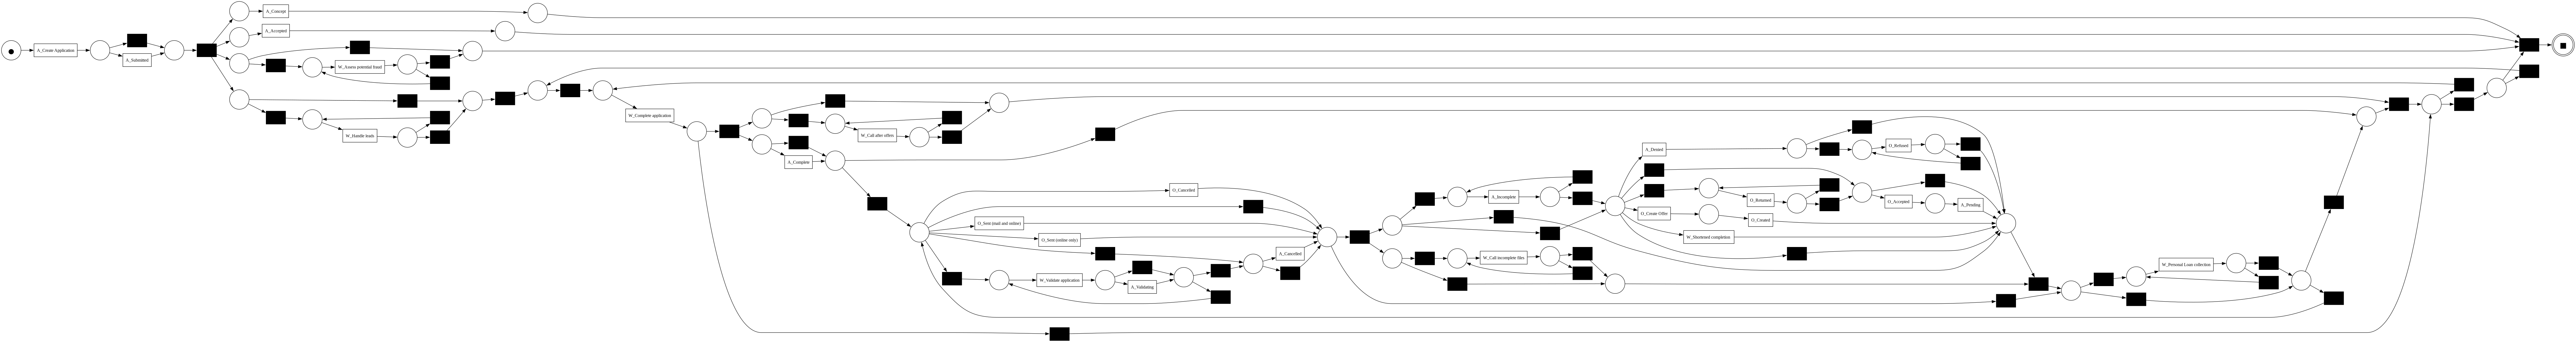

In [12]:
# Calculate and store markings:
import event_log_loader.petri_net_replay_markings
importlib.reload(event_log_loader.petri_net_replay_markings)
from event_log_loader.petri_net_replay_markings import InductiveMiner, PNReplayMarkings

# initialize the process 
miner = InductiveMiner(path_to_csv_log=event_log_location, case_id_col="case:concept:name", activity_col="concept:name", timestamp_col="time:timestamp", resource_col="org:resource")
net, im, fm = miner.discover_petri_net(visulaize=True, store_loc_file_path='../../../../encoded_data_v2/BPIC17/prefix_for_replay/petri_net/bpic17.png')

In [13]:
# train set markings
replayer_train = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=train_pref_df, event_label="concept:name")

markings_train = replayer_train.get_markings_token_replay()

print("Amount markings: ", len(markings_train))
markings_counter_train = Counter(tuple(mark) for mark in markings_train)
markings_summary_train = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_train.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_train

Amount markings:  779860


,marking,count
0,"[p_10, p_9, p_7, p_29, p_40]",133852
1,"[p_10, p_9, p_7, p_33, p_29]",70324
2,"[p_10, p_9, p_7, p_29, p_52, p_46]",67480
3,"[p_6, p_10, p_9, p_25]",46297
4,"[p_10, p_9, p_7, p_31, p_29]",40736
...,...,...
445,"[source, p_29, p_49, p_46, p_55]",1
446,"[p_9, p_13, p_7, p_29, p_46, p_54]",1
447,"[source, p_9, p_7, p_32, p_29, p_13, p_49, p_40]",1
448,"[p_9, p_13, p_7, p_29, p_43, p_63]",1


In [14]:
# train set markings
replayer_val = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=val_pref_df, event_label="concept:name")

markings_val = replayer_val.get_markings_token_replay()

print("Amount markings: ", len(markings_val))
markings_counter_val = Counter(tuple(mark) for mark in markings_val)
markings_summary_val = (pd.DataFrame([(list(mark), count) for mark, count in markings_counter_val.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_val

Amount markings:  181813


,marking,count
0,"[p_10, p_9, p_7, p_29, p_40]",31736
1,"[p_10, p_9, p_7, p_33, p_29]",16303
2,"[p_10, p_9, p_7, p_29, p_52, p_46]",15767
3,"[p_6, p_10, p_9, p_25]",10295
4,"[p_10, p_9, p_7, p_31, p_29]",9394
...,...,...
255,"[source, p_46, p_54]",1
256,"[p_9, p_7, p_29, p_13, p_46, p_55]",1
257,"[p_9, p_7, p_29, p_13, p_46, p_57]",1
258,"[p_9, p_7, p_29, p_13, p_57, p_46]",1


In [15]:
# train set markings
replayer_test = PNReplayMarkings(discovered_pn=(net, im, fm), prefix_df=test_pref_df, event_label="concept:name")

markings_test = replayer_test.get_markings_token_replay()

print("Amount markings: ", len(markings_test))
markings_counter_test = Counter(tuple(mark) for mark in markings_test)
markings_summary_test = ( pd.DataFrame([(list(mark), count) for mark, count in markings_counter_test.items()], columns=["marking", "count"]).sort_values("count", ascending=False).reset_index(drop=True))
markings_summary_test

Amount markings:  240594


,marking,count
0,"[p_10, p_9, p_7, p_29, p_40]",41240
1,"[p_10, p_9, p_7, p_33, p_29]",21635
2,"[p_10, p_9, p_7, p_29, p_52, p_46]",20912
3,"[p_6, p_10, p_9, p_25]",14264
4,"[p_10, p_9, p_7, p_31, p_29]",12524
...,...,...
282,"[source, p_9, p_7, p_29, p_46, p_63]",1
283,"[p_9, p_7, p_13, p_29, p_43, p_61]",1
284,"[p_9, p_7, p_13, p_36, p_29]",1
285,"[source, p_10, p_9, p_7, p_29, p_43, p_61]",1


## Dtore datasets and credentials for Deep-NN

In [16]:
# object to create the tensors for the dnn models and further credentials
el_loader = EventLogLoader(event_log_location=event_log_location, event_log_properties=event_log_properties, prefix_df=pref_adopt_dataframe)

In [17]:
# 
test_set = el_loader.get_encoded_dataframe(type='test')
test_set

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,...,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,case_elapsed_time,event_elapsed_time,day_in_week,seconds_in_day
0,Created,User_1,A_Create Application,Application,Application_1000086665,complete,2016-08-03 15:57:21.673,"Other, see explanation",New credit,Application_1000086665,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,2.0,57441.0
1,statechange,User_1,A_Submitted,Application,ApplState_161925113,complete,2016-08-03 15:57:21.734,"Other, see explanation",New credit,Application_1000086665,...,NaN,NaN,NaN,NaN,NaN,NaN,0.061000,0.061000,2.0,57441.0
2,Created,User_1,W_Handle leads,Workflow,Workitem_747707399,schedule,2016-08-03 15:57:21.963,"Other, see explanation",New credit,Application_1000086665,...,NaN,NaN,NaN,NaN,NaN,NaN,0.290000,0.229000,2.0,57441.0
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1030261128,withdraw,2016-08-03 15:58:28.286,"Other, see explanation",New credit,Application_1000086665,...,NaN,NaN,NaN,NaN,NaN,NaN,66.612999,66.322998,2.0,57508.0
4,Created,User_1,W_Complete application,Workflow,Workitem_1127124826,schedule,2016-08-03 15:58:28.293,"Other, see explanation",New credit,Application_1000086665,...,NaN,NaN,NaN,NaN,NaN,NaN,66.620003,0.007000,2.0,57508.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272094,EOS,EOS,EOS,EOS,EOS,EOS,NaT,EOS,EOS,Application_999544538,...,EOS,NaN,EOS,NaN,NaN,EOS,NaN,NaN,NaN,NaN
272095,EOS,EOS,EOS,EOS,EOS,EOS,NaT,EOS,EOS,Application_999544538,...,EOS,NaN,EOS,NaN,NaN,EOS,NaN,NaN,NaN,NaN
272096,EOS,EOS,EOS,EOS,EOS,EOS,NaT,EOS,EOS,Application_999544538,...,EOS,NaN,EOS,NaN,NaN,EOS,NaN,NaN,NaN,NaN
272097,EOS,EOS,EOS,EOS,EOS,EOS,NaT,EOS,EOS,Application_999544538,...,EOS,NaN,EOS,NaN,NaN,EOS,NaN,NaN,NaN,NaN


In [18]:
# train tensor dataset
train_set = el_loader.get_dataset('train')

# add markings to the train dataset credentials:
train_set.set_prefix_markings(markings=markings_train)

# save dataset 
torch.save(train_set, '../../../../encoded_data_v2/BPIC17/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_train.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/20482 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/20482 [00:00<?, ?it/s]

org:resource:   0%|          | 0/20482 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/20482 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/20482 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/20482 [00:00<?, ?it/s]

static categorical:   0%|          | 0/779860 [00:00<?, ?it/s]

static continuous:   0%|          | 0/779860 [00:00<?, ?it/s]

In [19]:
# Test get sizes and others
print("Min suffix size: ", train_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", train_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", train_set.all_static_categories)

print("Dynamic categorical tensor: ", train_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", train_set.continuous_tensors[0].size())

print("Static categorical tensor: ", train_set.static_categorical_tensor.size())
print("Static continuous tensor: ", train_set.static_continuous_tensor.size())

print("Zero padding tensor: ", train_set.zero_padding.size())
print("EOS padding tensor: ",train_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(train_set.prefixes_petri_net_marking))
print(train_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('lifecycle:transition', 9, {'EOS': 1, 'ate_abort': 2, 'complete': 3, 'resume': 4, 'schedule': 5, 'start': 6, 'suspend': 7, 'withdraw': 8}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 

In [20]:
# train tensor dataset
val_set = el_loader.get_dataset('val')

# add markings to the train dataset credentials:
val_set.set_prefix_markings(markings=markings_val)

# save dataset 
torch.save(val_set, '../../../../encoded_data_v2/BPIC17/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_val.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/4726 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/4726 [00:00<?, ?it/s]

org:resource:   0%|          | 0/4726 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/4726 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/4726 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/4726 [00:00<?, ?it/s]

static categorical:   0%|          | 0/181813 [00:00<?, ?it/s]

static continuous:   0%|          | 0/181813 [00:00<?, ?it/s]

In [21]:
# Test get sizes and others
print("Min suffix size: ", val_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", val_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", val_set.all_static_categories)

print("Dynamic categorical tensor: ", val_set.categorical_tensors[0].size())
print("Dynamic continuous tensor: ", val_set.continuous_tensors[0].size())

print("Static categorical tensor: ", val_set.static_categorical_tensor.size())
print("Static continuous tensor: ", val_set.static_continuous_tensor.size())

print("Zero padding tensor: ", val_set.zero_padding.size())
print("EOS padding tensor: ",val_set.eos_padding.size())

print("Prefix petri net replay tensor: ", len(val_set.prefixes_petri_net_marking))
print(val_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('lifecycle:transition', 9, {'EOS': 1, 'ate_abort': 2, 'complete': 3, 'resume': 4, 'schedule': 5, 'start': 6, 'suspend': 7, 'withdraw': 8}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 

In [22]:
# train tensor dataset
test_set = el_loader.get_dataset('test')

# add markings to the train dataset credentials:
test_set.set_prefix_markings(markings=markings_test)

# save dataset 
torch.save(test_set, '../../../../encoded_data_v2/BPIC17/'+result_name+'_'+str(el_loader.encoder_decoder.min_suffix_size)+'_test.pkl')

categorical tensors:   0%|          | 0/3 [00:00<?, ?it/s]

concept:name:   0%|          | 0/6301 [00:00<?, ?it/s]

lifecycle:transition:   0%|          | 0/6301 [00:00<?, ?it/s]

org:resource:   0%|          | 0/6301 [00:00<?, ?it/s]

continouous tensors:   0%|          | 0/4 [00:00<?, ?it/s]

...

event_elapsed_time:   0%|          | 0/6301 [00:00<?, ?it/s]

day_in_week:   0%|          | 0/6301 [00:00<?, ?it/s]

seconds_in_day:   0%|          | 0/6301 [00:00<?, ?it/s]

static categorical:   0%|          | 0/240594 [00:00<?, ?it/s]

static continuous:   0%|          | 0/240594 [00:00<?, ?it/s]

In [23]:
# Test get sizes and others
print("Min suffix size: ", test_set.min_suffix_size)

print("Categories and encoding params for dynamic categorical and continuous values: ", test_set.all_categories)
print("Categories and encoding params for static categorical and continuous values: ", test_set.all_static_categories)

print("Dynamic categorical tensor: ", test_set.categorical_tensors[0].size())
# print("Dynamic categorical tensor examples: ", test_set.categorical_tensors[0][10:55])
print("Dynamic continuous tensor: ", test_set.continuous_tensors[0].size())

print("Static categorical tensor: ", test_set.static_categorical_tensor.size())
print("Static continuous tensor: ", test_set.static_continuous_tensor.size())

print("Zero padding tensor: ", test_set.zero_padding.size())
print("EOS padding tensor: ",test_set.eos_padding.size())
# print("Zero padds: ", test_set.zero_padding[35:41])
# print("EOS padds: ", test_set.eos_padding[35:41])

print("Prefix petri net replay tensor: ", len(test_set.prefixes_petri_net_marking))
print(test_set.prefixes_petri_net_marking[0:3])

Min suffix size:  5
Categories and encoding params for dynamic categorical and continuous values:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('lifecycle:transition', 9, {'EOS': 1, 'ate_abort': 2, 'complete': 3, 'resume': 4, 'schedule': 5, 'start': 6, 'suspend': 7, 'withdraw': 8}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 